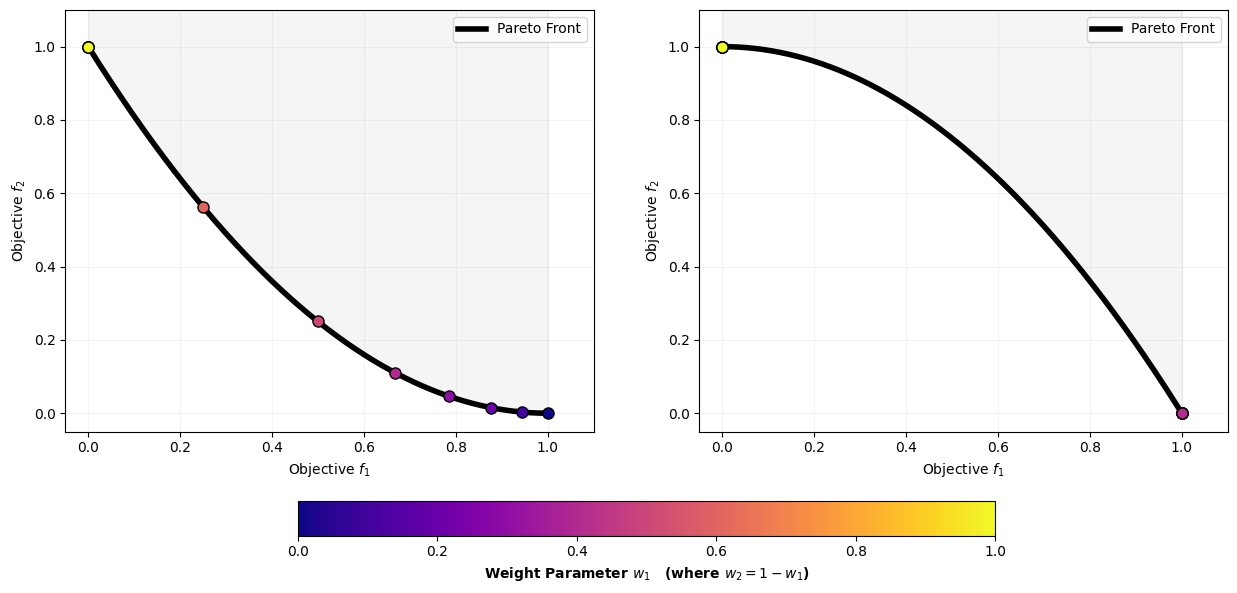

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.transforms import Bbox

def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels() 
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(1.0 + pad, 1.0 + pad)

# =====================================================================
# 1. Generate the Objective Space Profiles directly
# =====================================================================
f1_line = np.linspace(0.0, 1.0, 500)

# Convex profile: f2 = (1 - f1)^2
convex_f2 = (1.0 - f1_line)**2

# Non-convex profile: f2 = 1 - f1^2
nonconvex_f2 = 1.0 - f1_line**2

# Create a clean sweep of 11 weight vectors from w1=0 to w1=1
w1_sweep = np.linspace(0.0, 1.0, 11)

# =====================================================================
# 2. Render the Multiple-Weight Line Sweeps
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))
colors = plt.cm.plasma(np.linspace(0, 1, len(w1_sweep)))

# --- PANEL 1: CONVEX BOUNDARY LINE SWEEP ---
ax1.plot(f1_line, convex_f2, color='black', lw=4, label='Pareto Front', zorder=4)
ax1.fill_between(f1_line, convex_f2, 1.5, color='gray', alpha=0.08)

for idx, w1 in enumerate(w1_sweep):
    w2 = 1.0 - w1
    if w2 == 0: w2 = 1e-6 # Avoid division by zero for vertical line
    
    # Evaluate every point on the front to find the minimum cost value c
    costs = w1 * f1_line + w2 * convex_f2
    opt_idx = np.argmin(costs)
    c = costs[opt_idx]
    
    # Plot the specific tangent line: f2 = (c - w1*f1)/w2
    # Limit line drawing near the optimal zone so the plot stays readable
    f2_tangent = (c - w1 * f1_line) / w2
    # ax1.plot(f1_line, f2_tangent, color=colors[idx], linestyle='--', alpha=0.6, lw=1.5)
    
    # Plot the geometric solution point
    ax1.plot(f1_line[opt_idx], convex_f2[opt_idx], 'o', color=colors[idx], 
             markersize=8, markeredgecolor='black', zorder=5)

# ax1.set_title('Convex Front: Every Weight Slopes into a Unique Solution', fontsize=11, weight='bold')
ax1.set_xlabel('Objective $f_1$')
ax1.set_ylabel('Objective $f_2$')
ax1.set_xlim(-0.05, 1.1)
ax1.set_ylim(-0.05, 1.1)
ax1.grid(True, alpha=0.15)
ax1.legend(loc='upper right')

# --- PANEL 2: NON-CONVEX BOUNDARY LINE SWEEP ---
ax2.plot(f1_line, nonconvex_f2, color='black', lw=4, label='Pareto Front', zorder=4)
ax2.fill_between(f1_line, nonconvex_f2, 1.5, color='gray', alpha=0.08)

for idx, w1 in enumerate(w1_sweep):
    w2 = 1.0 - w1
    if w2 == 0: w2 = 1e-6
    
    # Evaluate every point on the non-convex arc to find the minimum cost value c
    costs = w1 * f1_line + w2 * nonconvex_f2
    opt_idx = np.argmin(costs)
    c = costs[opt_idx]
    
    # Plot the specific tangent line
    f2_tangent = (c - w1 * f1_line) / w2
    # ax2.plot(f1_line, f2_tangent, color=colors[idx], linestyle='--', alpha=0.6, lw=1.5)
    
    # Plot the geometric solution point
    ax2.plot(f1_line[opt_idx], nonconvex_f2[opt_idx], 'o', color=colors[idx], 
             markersize=8, markeredgecolor='black', zorder=5)

# Highlighting the visual void in the center
# ax2.text(0.5, 0.4, 'The Non-Convex Void\n\nNo linear line can touch the\ninterior curve without cutting\nthrough a corner point first.', 
         # color='red', weight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.95, edgecolor='red', boxstyle='round,pad=0.8'))

# ax2.set_title('Non-Convex Front: All Weights Snap to Extreme Corners', fontsize=11, weight='bold')
ax2.set_xlabel('Objective $f_1$')
ax2.set_ylabel('Objective $f_2$')
ax2.set_xlim(-0.05, 1.1)
ax2.set_ylim(-0.05, 1.1)
ax2.grid(True, alpha=0.15)
ax2.legend(loc='upper right')

# Add a shared colorbar to show the weight vector transition
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='horizontal', pad=0.12, shrink=0.6)
cbar.set_label('Weight Parameter $w_1$   (where $w_2 = 1 - w_1$)', weight='bold', fontsize=10)

plt.savefig('objective_space_weight_sweep.pdf', format='pdf', bbox_inches='tight')

extent = full_extent(ax1).transformed(fig.dpi_scale_trans.inverted())
# Alternatively,
# extent = ax.get_tightbbox(fig.canvas.renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('convex_WS.png', bbox_inches=extent)

extent = full_extent(ax2).transformed(fig.dpi_scale_trans.inverted())
# Alternatively,
# extent = ax.get_tightbbox(fig.canvas.renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('concave_WS.png', bbox_inches=extent)
plt.show()

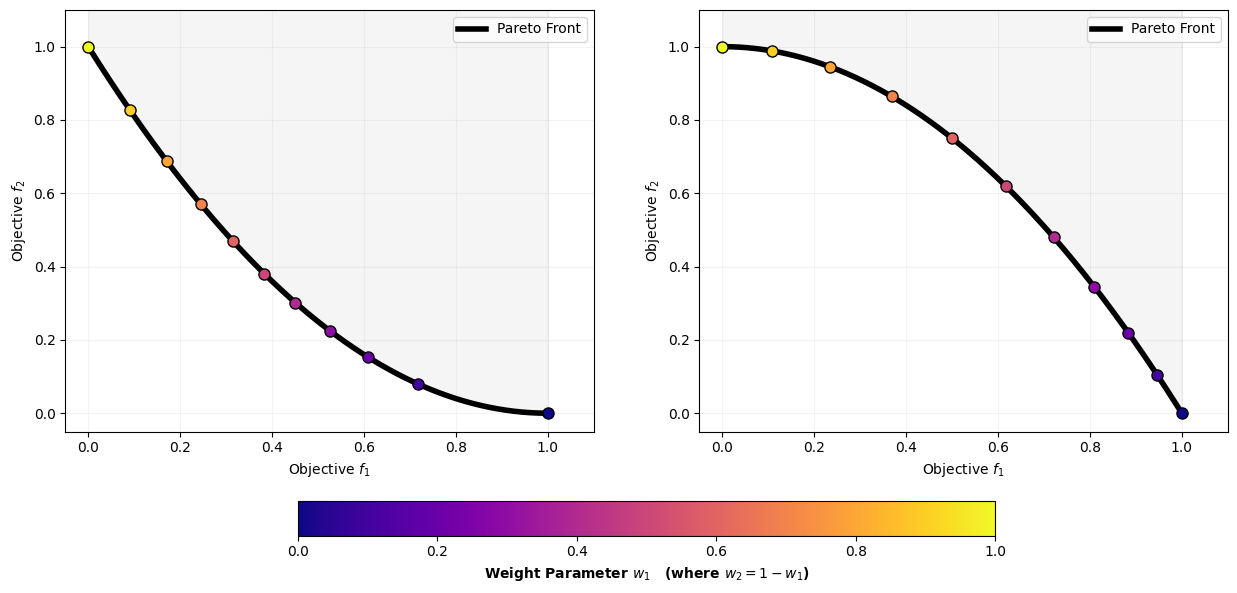

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.transforms import Bbox

def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels() 
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(1.0 + pad, 1.0 + pad)

# =====================================================================
# 1. Generate the Objective Space Profiles directly
# =====================================================================
f1_line = np.linspace(0.0, 1.0, 500)

# Convex profile: f2 = (1 - f1)^2
convex_f2 = (1.0 - f1_line)**2

# Non-convex profile: f2 = 1 - f1^2
nonconvex_f2 = 1.0 - f1_line**2

# Create a clean sweep of 11 weight vectors from w1=0 to w1=1
w1_sweep = np.linspace(0.0, 1.0, 11)

# =====================================================================
# 2. Render the Multiple-Weight Line Sweeps
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))
colors = plt.cm.plasma(np.linspace(0, 1, len(w1_sweep)))

# --- PANEL 1: CONVEX BOUNDARY LINE SWEEP ---
ax1.plot(f1_line, convex_f2, color='black', lw=4, label='Pareto Front', zorder=4)
ax1.fill_between(f1_line, convex_f2, 1.5, color='gray', alpha=0.08)

for idx, w1 in enumerate(w1_sweep):
    w2 = 1.0 - w1
    if w2 == 0: w2 = 1e-6 # Avoid division by zero for vertical line
    
    # Evaluate every point on the front to find the minimum cost value c
    # costs = w1 * f1_line + w2 * convex_f2
    costs = np.max((w1 * f1_line, w2 * convex_f2),axis=0)
    opt_idx = np.argmin(costs)
    c = costs[opt_idx]
    
    # Plot the specific tangent line: f2 = (c - w1*f1)/w2
    # Limit line drawing near the optimal zone so the plot stays readable
    f2_tangent = (c - w1 * f1_line) / w2
    # ax1.plot(f1_line, f2_tangent, color=colors[idx], linestyle='--', alpha=0.6, lw=1.5)
    
    # Plot the geometric solution point
    ax1.plot(f1_line[opt_idx], convex_f2[opt_idx], 'o', color=colors[idx], 
             markersize=8, markeredgecolor='black', zorder=5)

# ax1.set_title('Convex Front: Every Weight Slopes into a Unique Solution', fontsize=11, weight='bold')
ax1.set_xlabel('Objective $f_1$')
ax1.set_ylabel('Objective $f_2$')
ax1.set_xlim(-0.05, 1.1)
ax1.set_ylim(-0.05, 1.1)
ax1.grid(True, alpha=0.15)
ax1.legend(loc='upper right')

# --- PANEL 2: NON-CONVEX BOUNDARY LINE SWEEP ---
ax2.plot(f1_line, nonconvex_f2, color='black', lw=4, label='Pareto Front', zorder=4)
ax2.fill_between(f1_line, nonconvex_f2, 1.5, color='gray', alpha=0.08)

for idx, w1 in enumerate(w1_sweep):
    w2 = 1.0 - w1
    if w2 == 0: w2 = 1e-6
    
    # Evaluate every point on the non-convex arc to find the minimum cost value c
    costs = w1 * f1_line + w2 * nonconvex_f2
    costs = np.max((w1 * f1_line,w2 * nonconvex_f2),axis=0)
    opt_idx = np.argmin(costs)
    c = costs[opt_idx]
    
    # Plot the specific tangent line
    f2_tangent = (c - w1 * f1_line) / w2
    # ax2.plot(f1_line, f2_tangent, color=colors[idx], linestyle='--', alpha=0.6, lw=1.5)
    
    # Plot the geometric solution point
    ax2.plot(f1_line[opt_idx], nonconvex_f2[opt_idx], 'o', color=colors[idx], 
             markersize=8, markeredgecolor='black', zorder=5)

# Highlighting the visual void in the center
# ax2.text(0.5, 0.4, 'The Non-Convex Void\n\nNo linear line can touch the\ninterior curve without cutting\nthrough a corner point first.', 
         # color='red', weight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.95, edgecolor='red', boxstyle='round,pad=0.8'))

# ax2.set_title('Non-Convex Front: All Weights Snap to Extreme Corners', fontsize=11, weight='bold')
ax2.set_xlabel('Objective $f_1$')
ax2.set_ylabel('Objective $f_2$')
ax2.set_xlim(-0.05, 1.1)
ax2.set_ylim(-0.05, 1.1)
ax2.grid(True, alpha=0.15)
ax2.legend(loc='upper right')

# Add a shared colorbar to show the weight vector transition
sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=0, vmax=1))
cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='horizontal', pad=0.12, shrink=0.6)
cbar.set_label('Weight Parameter $w_1$   (where $w_2 = 1 - w_1$)', weight='bold', fontsize=10)

plt.savefig('objective_space_weight_sweep_TCH.pdf', format='pdf', bbox_inches='tight')

extent = full_extent(ax1).transformed(fig.dpi_scale_trans.inverted())
# Alternatively,
# extent = ax.get_tightbbox(fig.canvas.renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('convex_TCH.png', bbox_inches=extent)

extent = full_extent(ax2).transformed(fig.dpi_scale_trans.inverted())
# Alternatively,
# extent = ax.get_tightbbox(fig.canvas.renderer).transformed(fig.dpi_scale_trans.inverted())
fig.savefig('concave_TCH.png', bbox_inches=extent)
plt.show()